In [1]:
from typing import TypedDict, Annotated, Dict, Optional
from langgraph.graph import StateGraph, END, add_messages
from langchain_groq import ChatGroq
from langchain_tavily import TavilySearch
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AIMessage, HumanMessage, ToolMessage
from uuid import uuid4
from dotenv import load_dotenv

load_dotenv()

llm = ChatGroq(
    model="llama-3.1-8b-instant",
    temperature=0.7,
    max_tokens=1024
)

C:\Users\Jay Pawar\AppData\Roaming\Python\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#create the search tool
search_tool = TavilySearch(
    max_results=3,
    include_raw_content=False,
    include_answer=True,
    search_depth="advanced"
)

tools = [search_tool]

#create the MemorySaver for the history
memory = MemorySaver()

In [3]:
llm_with_tools = llm.bind_tools(tools=tools)

result = llm_with_tools.invoke("what is current weather in Kolhapur")
result

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '0dbgxzq9r', 'function': {'arguments': '{"query":"Kolhapur current weather","search_depth":"basic","topic":"general"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 1794, 'total_tokens': 1828, 'completion_time': 0.048629414, 'prompt_time': 0.098887754, 'queue_time': 0.050456166, 'total_time': 0.147517168}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_f757f4b0bf', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--68af89bf-d187-4b26-8647-f9cdbe0e588f-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Kolhapur current weather', 'search_depth': 'basic', 'topic': 'general'}, 'id': '0dbgxzq9r', 'type': 'tool_call'}], usage_metadata={'input_tokens': 1794, 'output_tokens': 34, 'total_tokens': 1828})

In [4]:
#TypedDict allows us to create kind of interface that we must follow
class State(TypedDict):
    messages: Annotated[list, add_messages]

async def model(state: State):
    result = await llm_with_tools.ainvoke(state["messages"])
    return {
        "messages": [result]
    }

async def tool_router(state: State):
    last_message = state['messages'][-1]

    if(hasattr(last_message, "tool_calls") and len(last_message.tool_calls) > 0):
        return "tool_node"
    else:
        return END

async def tool_node(state: State):
    """custom tool node that handles tool calss from llm"""
    #get the tool calls from the last message
    tool_calls = state["messages"][-1].tool_calls

    #initialize list to store tool messages
    tool_messages = []

    #process each toll call
    for tool_call in tool_calls:
        tool_name = tool_call["name"]
        tool_args = tool_call["args"]
        tool_id = tool_call["id"]

        #Handle search tool
        if tool_name == "tavily_search":
            #Execute the serach tool with provided argument
            search_results = await search_tool.ainvoke(tool_args)

            #ToolMEssage is a message sent to the LLM containing the result of a tool execution.
            tool_message = ToolMessage(
                content=str(search_results), 
                tool_call_id=tool_id, 
                tool_name=tool_name
            )

            tool_messages.append(tool_message)

    #Add the tool message to the state
    return {"messages": tool_messages}

Create the graph


In [5]:
graph_builder = StateGraph(State)

graph_builder.add_node("model", model)
graph_builder.add_node("tool_node", tool_node)
graph_builder.set_entry_point("model")

graph_builder.add_conditional_edges("model", tool_router)
graph_builder.add_edge("tool_node", "model")

graph = graph_builder.compile(checkpointer=memory)

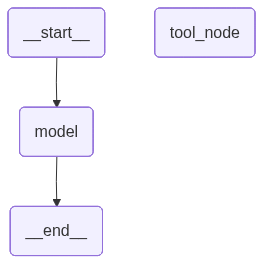

In [6]:
from IPython.display import display, Image
from langchain_core.runnables.graph import MermaidDrawMethod

display(
    Image(
        graph.get_graph().draw_mermaid_png(draw_method=MermaidDrawMethod.API)
    )
)

In [7]:
config = {"configurable": {"thread_id": 1}}

response = await graph.ainvoke({
    "messages": [HumanMessage(content="How are you doing?")] 
}, config=config)

response

{'messages': [HumanMessage(content='How are you doing?', additional_kwargs={}, response_metadata={}, id='f6283454-6e90-4d89-83c1-0d06d6df1892'),
  AIMessage(content="I'm functioning within normal parameters.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 1791, 'total_tokens': 1799, 'completion_time': 0.012642737, 'prompt_time': 0.099850471, 'queue_time': 0.055464009, 'total_time': 0.112493208}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'finish_reason': 'stop', 'logprobs': None}, id='run--3f4d5f64-1462-4866-8c35-99744cc29bf8-0', usage_metadata={'input_tokens': 1791, 'output_tokens': 8, 'total_tokens': 1799})]}

In [8]:
response = await graph.ainvoke({
    "messages": [HumanMessage(content="What was my last question")] 
}, config=config)

response

{'messages': [HumanMessage(content='How are you doing?', additional_kwargs={}, response_metadata={}, id='f6283454-6e90-4d89-83c1-0d06d6df1892'),
  AIMessage(content="I'm functioning within normal parameters.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 1791, 'total_tokens': 1799, 'completion_time': 0.012642737, 'prompt_time': 0.099850471, 'queue_time': 0.055464009, 'total_time': 0.112493208}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'finish_reason': 'stop', 'logprobs': None}, id='run--3f4d5f64-1462-4866-8c35-99744cc29bf8-0', usage_metadata={'input_tokens': 1791, 'output_tokens': 8, 'total_tokens': 1799}),
  HumanMessage(content='What was my last question', additional_kwargs={}, response_metadata={}, id='7a36b22d-7e37-4156-9152-ff60e30eac4e'),
  AIMessage(content='Your last question was about how I was doing.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prom

In [9]:
response = await graph.ainvoke({
    "messages": [HumanMessage(content="What is current weather in Kolhapur")] 
}, config=config)

response

{'messages': [HumanMessage(content='How are you doing?', additional_kwargs={}, response_metadata={}, id='f6283454-6e90-4d89-83c1-0d06d6df1892'),
  AIMessage(content="I'm functioning within normal parameters.", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 8, 'prompt_tokens': 1791, 'total_tokens': 1799, 'completion_time': 0.012642737, 'prompt_time': 0.099850471, 'queue_time': 0.055464009, 'total_time': 0.112493208}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'finish_reason': 'stop', 'logprobs': None}, id='run--3f4d5f64-1462-4866-8c35-99744cc29bf8-0', usage_metadata={'input_tokens': 1791, 'output_tokens': 8, 'total_tokens': 1799}),
  HumanMessage(content='What was my last question', additional_kwargs={}, response_metadata={}, id='7a36b22d-7e37-4156-9152-ff60e30eac4e'),
  AIMessage(content='Your last question was about how I was doing.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 11, 'prom

Give Response Using Streaming

In [10]:
config = {"configurable": {"thread_id": 2}}

async for event in graph.astream_events({
    "messages": [HumanMessage(content="What is current weather in Kolhapur")] 
}, config=config, version="v2"):
    print(event)
    # if event["event"] == "on_chat_model_stream":
    #     print(event["data"]["chunk"].content, end="", flush=True)

{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='What is current weather in Kolhapur', additional_kwargs={}, response_metadata={})]}}, 'name': 'LangGraph', 'tags': [], 'run_id': '51b5b89d-078d-4d40-946d-bc5b83636aee', 'metadata': {'thread_id': 2}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='What is current weather in Kolhapur', additional_kwargs={}, response_metadata={}, id='25f06d85-7026-4308-bb88-175def6d52a4')]}}, 'name': 'model', 'tags': ['graph:step:1'], 'run_id': 'ab05620c-31c5-4b48-a6c9-b9a09ea31178', 'metadata': {'thread_id': 2, 'langgraph_step': 1, 'langgraph_node': 'model', 'langgraph_triggers': ('branch:to:model',), 'langgraph_path': ('__pregel_pull', 'model'), 'langgraph_checkpoint_ns': 'model:75993f55-2338-eb99-d841-116535b3f6c2'}, 'parent_ids': ['51b5b89d-078d-4d40-946d-bc5b83636aee']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='What is curr